In [3]:
from pathlib import Path
import pandas as pd

# Trouver la racine du projet (le dossier qui contient "data")
ROOT = Path().resolve()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

print("Project ROOT =", ROOT)

TX_GOLD = ROOT / "data" / "gold" / "transactions_gold.parquet"
SILVER_CLEAN = ROOT / "data" / "silver" / "transactions_clean.parquet"

print("TX_GOLD exists:", TX_GOLD.exists(), TX_GOLD)
print("SILVER_CLEAN exists:", SILVER_CLEAN.exists(), SILVER_CLEAN)

tx_gold = pd.read_parquet(TX_GOLD)
silver = pd.read_parquet(SILVER_CLEAN)

print("tx_gold:", tx_gold.shape)
print("silver:", silver.shape)

Project ROOT = C:\Users\HP\Desktop\fraud-lakehouse-project
TX_GOLD exists: True C:\Users\HP\Desktop\fraud-lakehouse-project\data\gold\transactions_gold.parquet
SILVER_CLEAN exists: True C:\Users\HP\Desktop\fraud-lakehouse-project\data\silver\transactions_clean.parquet
tx_gold: (1048575, 28)
silver: (1048575, 13)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ROOT déjà trouvé chez toi (tu peux relancer ce bloc si besoin)
ROOT = Path(r"C:\Users\HP\Desktop\fraud-lakehouse-project")

TX_GOLD = ROOT / "data" / "gold" / "transactions_gold.parquet"
SILVER_CLEAN = ROOT / "data" / "silver" / "transactions_clean.parquet"

tx_gold = pd.read_parquet(TX_GOLD)
silver = pd.read_parquet(SILVER_CLEAN)

# BI-ready = Gold features + colonnes business + label fraude
tx = tx_gold.copy()
tx["isFraud"] = silver["isFraud"].values
tx["type"] = silver["type"].values
tx["amount"] = silver["amount"].values
tx["step"] = silver["step"].values

print(" tx BI-ready:", tx.shape)
tx.head(3)

 tx BI-ready: (1048575, 29)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,...,is_large_p99,abs_balance_diff_orig,abs_balance_diff_dest,is_incoherent_orig,is_incoherent_dest,orig_balance_before,dest_balance_before,orig_rel_amount,dest_rel_amount,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,0,0.0,9839.64,0,1,170136.0,NaN,0.057834,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,0,0.0,1864.28,0,1,21249.0,NaN,0.087735,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0,...,0,0.0,181.00,0,1,181.0,NaN,1.000000,0.0,1


In [5]:
total_tx = len(tx)
fraud_tx = int(tx["isFraud"].sum())
fraud_rate = tx["isFraud"].mean()

print(f"Total transactions: {total_tx:,}")
print(f"Fraud transactions: {fraud_tx:,}")
print(f"Fraud rate: {fraud_rate:.4%}")

Total transactions: 1,048,575
Fraud transactions: 1,142
Fraud rate: 0.1089%


In [6]:
fraud_by_type = (
    tx.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"count":"n_tx", "sum":"n_fraud", "mean":"fraud_rate"})
      .sort_values("fraud_rate", ascending=False)
)

fraud_by_type

,n_tx,n_fraud,fraud_rate
type,,,
TRANSFER,86753,564,0.006501
CASH_OUT,373641,578,0.001547
CASH_IN,227130,0,0.000000
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000


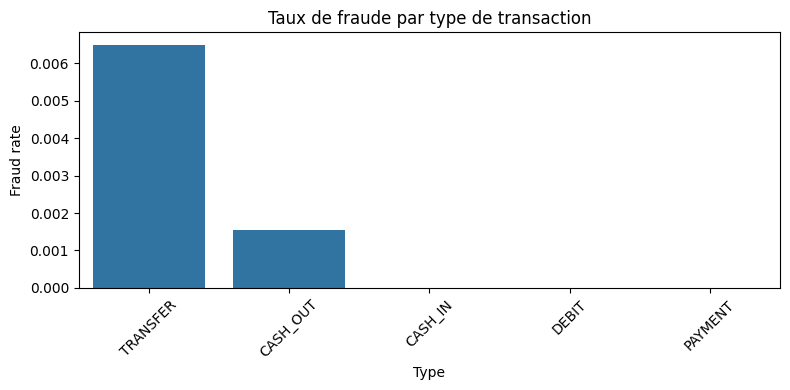

In [7]:
plt.figure(figsize=(8,4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type["fraud_rate"])
plt.xticks(rotation=45)
plt.title("Taux de fraude par type de transaction")
plt.xlabel("Type")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()

In [8]:
tx["amount_decile"] = pd.qcut(tx["amount"], q=10, duplicates="drop")
fraud_by_amount = tx.groupby("amount_decile")["isFraud"].mean()

fraud_by_amount

C:\Users\HP\AppData\Local\Temp\ipykernel_4656\3411066386.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = tx.groupby("amount_decile")["isFraud"].mean()


amount_decile
(0.099, 4220.57]            0.000343
(4220.57, 9073.24]          0.000114
(9073.24, 16245.618]        0.000362
(16245.618, 33790.7]        0.000811
(33790.7, 76343.33]         0.000877
(76343.33, 125528.736]      0.000896
(125528.736, 181279.868]    0.000687
(181279.868, 252361.842]    0.000553
(252361.842, 373075.378]    0.001011
(373075.378, 10000000.0]    0.005236
Name: isFraud, dtype: float64

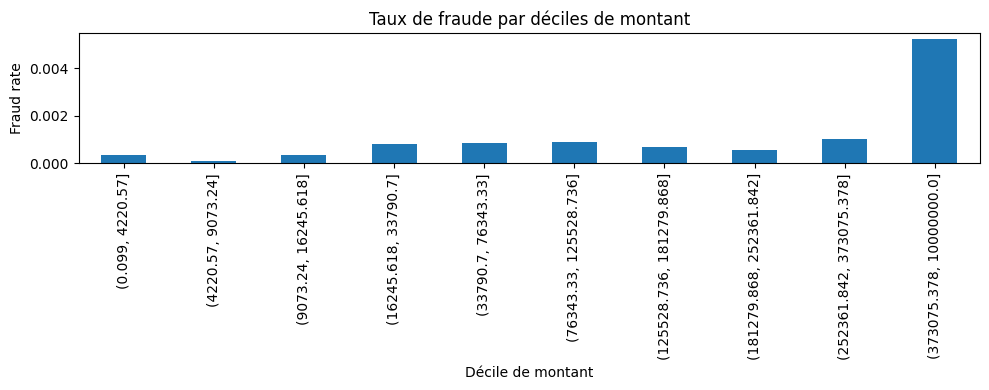

In [9]:
plt.figure(figsize=(10,4))
fraud_by_amount.plot(kind="bar")
plt.title("Taux de fraude par déciles de montant")
plt.xlabel("Décile de montant")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()

In [10]:
cols = [c for c in ["is_incoherent_orig", "is_incoherent_dest"] if c in tx.columns]
print("Colonnes testées:", cols)

tx.groupby("isFraud")[cols].mean()

Colonnes testées: ['is_incoherent_orig', 'is_incoherent_dest']


,is_incoherent_orig,is_incoherent_dest
isFraud,,
0,0.795824,0.764563
1,0.021016,0.640105


In [11]:
numeric_cols = tx.select_dtypes(include=["int64","int32","int16","int8","float64","float32"]).columns
corr = tx[numeric_cols].corr(numeric_only=True)["isFraud"].sort_values(ascending=False)

corr.head(15)

isFraud                  1.000000
amount                   0.128862
is_large_p99             0.077465
is_large_p95             0.053849
step                     0.045030
balance_diff_dest        0.041580
abs_balance_diff_dest    0.039257
amount_log               0.031750
balance_diff_orig        0.020029
oldbalanceOrg            0.003829
dest_rel_amount          0.000025
newbalanceDest          -0.000495
orig_balance_before     -0.000642
orig_rel_amount         -0.001173
dest_balance_before     -0.003974
Name: isFraud, dtype: float64

In [12]:
tx.groupby("isFraud")[["is_incoherent_orig","is_incoherent_dest"]].mean()

,is_incoherent_orig,is_incoherent_dest
isFraud,,
0,0.795824,0.764563
1,0.021016,0.640105
